In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings("ignore")

# STEP i  —  Load Dataset
# ───────────────────────
print("     HEALTHCARE DATASET NORMALIZATION")
df = pd.read_csv("healthcare.csv")
print(f"\n[1] Dataset Loaded  →  {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head(5).to_string(index=False))
features = ["Age", "BMI", "BloodPressure", "Glucose",
            "Insulin", "Cholesterol", "HeartRate", "HbA1c"]
X = df[features].copy()
print(f"\n[2] Original Data — Statistical Summary:")
print(X.describe().round(2).to_string())

     HEALTHCARE DATASET NORMALIZATION

[1] Dataset Loaded  →  30 rows × 9 columns
 PatientID  Age  BMI  BloodPressure  Glucose  Insulin  Cholesterol  HeartRate  HbA1c
         1   45 28.5             85      110     15.5          195         72    5.6
         2   62 34.2             92      145     22.3          240         88    7.2
         3   38 22.1             78       95     10.2          178         65    5.1
         4   55 31.7             98      160     28.7          260         95    8.1
         5   29 19.8             70       88      8.5          165         60    4.8

[2] Original Data — Statistical Summary:
         Age    BMI  BloodPressure  Glucose  Insulin  Cholesterol  HeartRate  HbA1c
count  30.00  30.00          30.00    30.00    30.00        30.00      30.00  30.00
mean   49.27  28.42          87.23   129.50    20.01       219.43      79.57   6.60
std    13.61   5.59          11.58    31.79     8.81        40.99      13.80   1.48
min    27.00  18.50          6

In [16]:
# STEP ii  —  Min-Max Normalization  
# ────────────────────────────────
mm_scaler = MinMaxScaler()
X_mm = pd.DataFrame(mm_scaler.fit_transform(X), columns=features)

print(f"\n[3] Min-Max Normalized Data (first 10 rows):")
print(X_mm.head(10).round(4).to_string(index=False))


[3] Min-Max Normalized Data (first 10 rows):
   Age    BMI  BloodPressure  Glucose  Insulin  Cholesterol  HeartRate  HbA1c
0.4091 0.5556         0.4595   0.2632   0.2810        0.280     0.3333 0.2273
0.7955 0.8722         0.6486   0.6316   0.5292        0.640     0.7143 0.5909
0.2500 0.2000         0.2703   0.1053   0.0876        0.144     0.1667 0.1136
0.6364 0.7333         0.8108   0.7895   0.7628        0.800     0.8810 0.7955
0.0455 0.0722         0.0541   0.0316   0.0255        0.040     0.0476 0.0455
1.0000 1.0000         1.0000   1.0000   1.0000        1.000     1.0000 1.0000
0.4773 0.4333         0.3784   0.3684   0.3759        0.360     0.4048 0.3182
0.1364 0.2722         0.1892   0.1579   0.1533        0.176     0.2381 0.1591
0.7500 0.8111         0.7297   0.7368   0.6460        0.720     0.7619 0.7273
0.3409 0.5167         0.5405   0.3158   0.3285        0.320     0.3810 0.2727


In [17]:
# STEP iii  —  Standard Scaler 
# ───────────────────────────
ss_scaler = StandardScaler()
X_ss = pd.DataFrame(ss_scaler.fit_transform(X), columns=features)
print(f"\n[4] Standard Scaled Data (first 10 rows):")
print(X_ss.head(10).round(4).to_string(index=False))
n_feat = len(features)


[4] Standard Scaled Data (first 10 rows):
    Age     BMI  BloodPressure  Glucose  Insulin  Cholesterol  HeartRate   HbA1c
-0.3190  0.0140        -0.1961  -0.6238  -0.5207      -0.6062    -0.5578 -0.6915
 0.9519  1.0520         0.4185   0.4959   0.2644       0.5103     0.6216  0.4113
-0.8423 -1.1515        -0.8107  -1.1037  -1.1326      -1.0281    -1.0737 -1.0362
 0.4286  0.5967         0.9453   0.9757   1.0033       1.0065     1.1376  1.0316
-1.5151 -1.5703        -1.5131  -1.3276  -1.3289      -1.3506    -1.4423 -1.2429
 1.6247  1.4708         1.5600   1.6155   1.7538       1.6269     1.5062  1.6519
-0.0947 -0.3867        -0.4595  -0.3039  -0.2205      -0.3581    -0.3366 -0.4158
-1.2161 -0.9148        -1.0741  -0.9437  -0.9248      -0.9288    -0.8526 -0.8983
 0.8024  0.8516         0.6819   0.8158   0.6338       0.7584     0.7691  0.8248
-0.5432 -0.1135         0.0673  -0.4639  -0.3706      -0.4822    -0.4103 -0.5537


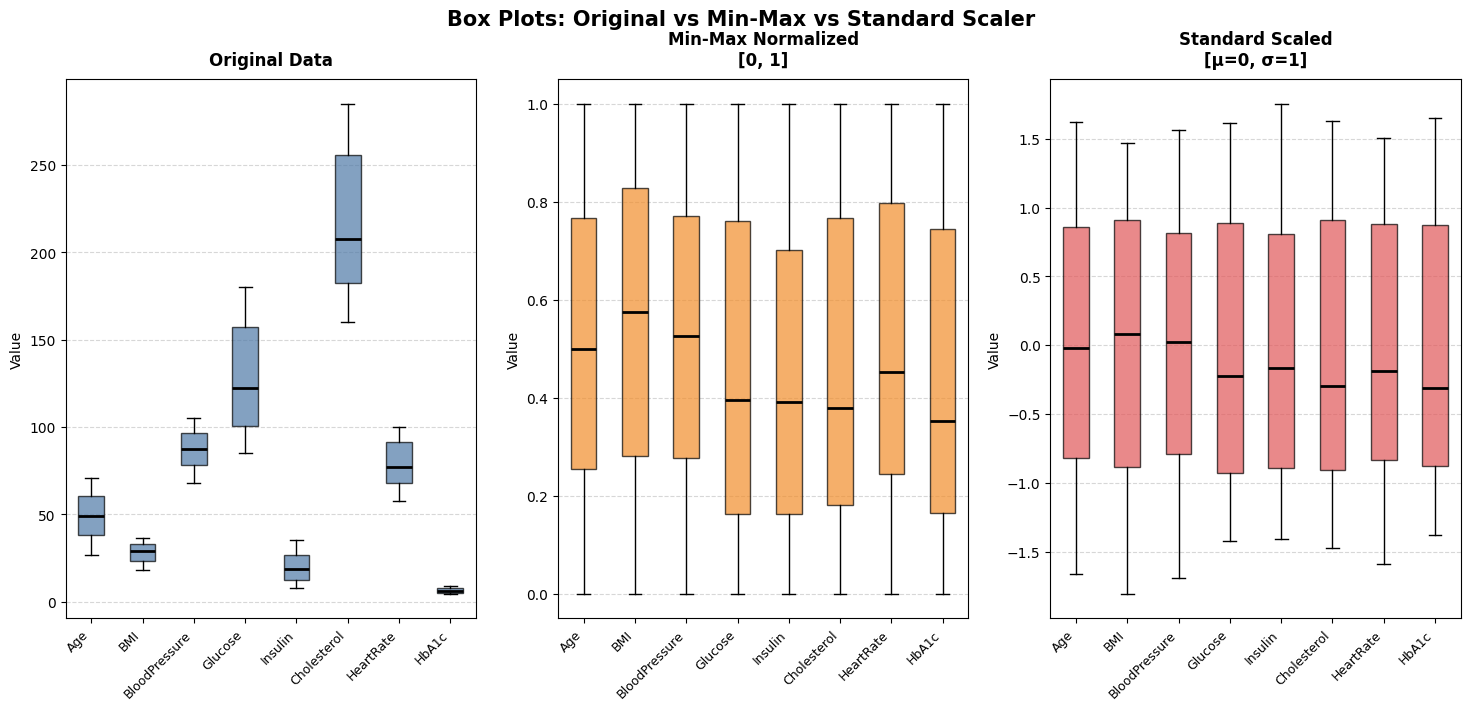

In [18]:
# PLOT 1  —  Box Plots  
# ════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18,7))
fig.suptitle("Box Plots: Original vs Min-Max vs Standard Scaler",
             fontsize=15, fontweight="bold")

for ax, data, title, color in zip(
        axes,
        [X, X_mm, X_ss],
        ["Original Data", "Min-Max Normalized\n[0, 1]", "Standard Scaled\n[μ=0, σ=1]"],
        ["#4e79a7", "#f28e2b", "#e15759"]):
    bp = ax.boxplot(data.values, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(range(1, n_feat + 1))
    ax.set_xticklabels(features, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Value", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

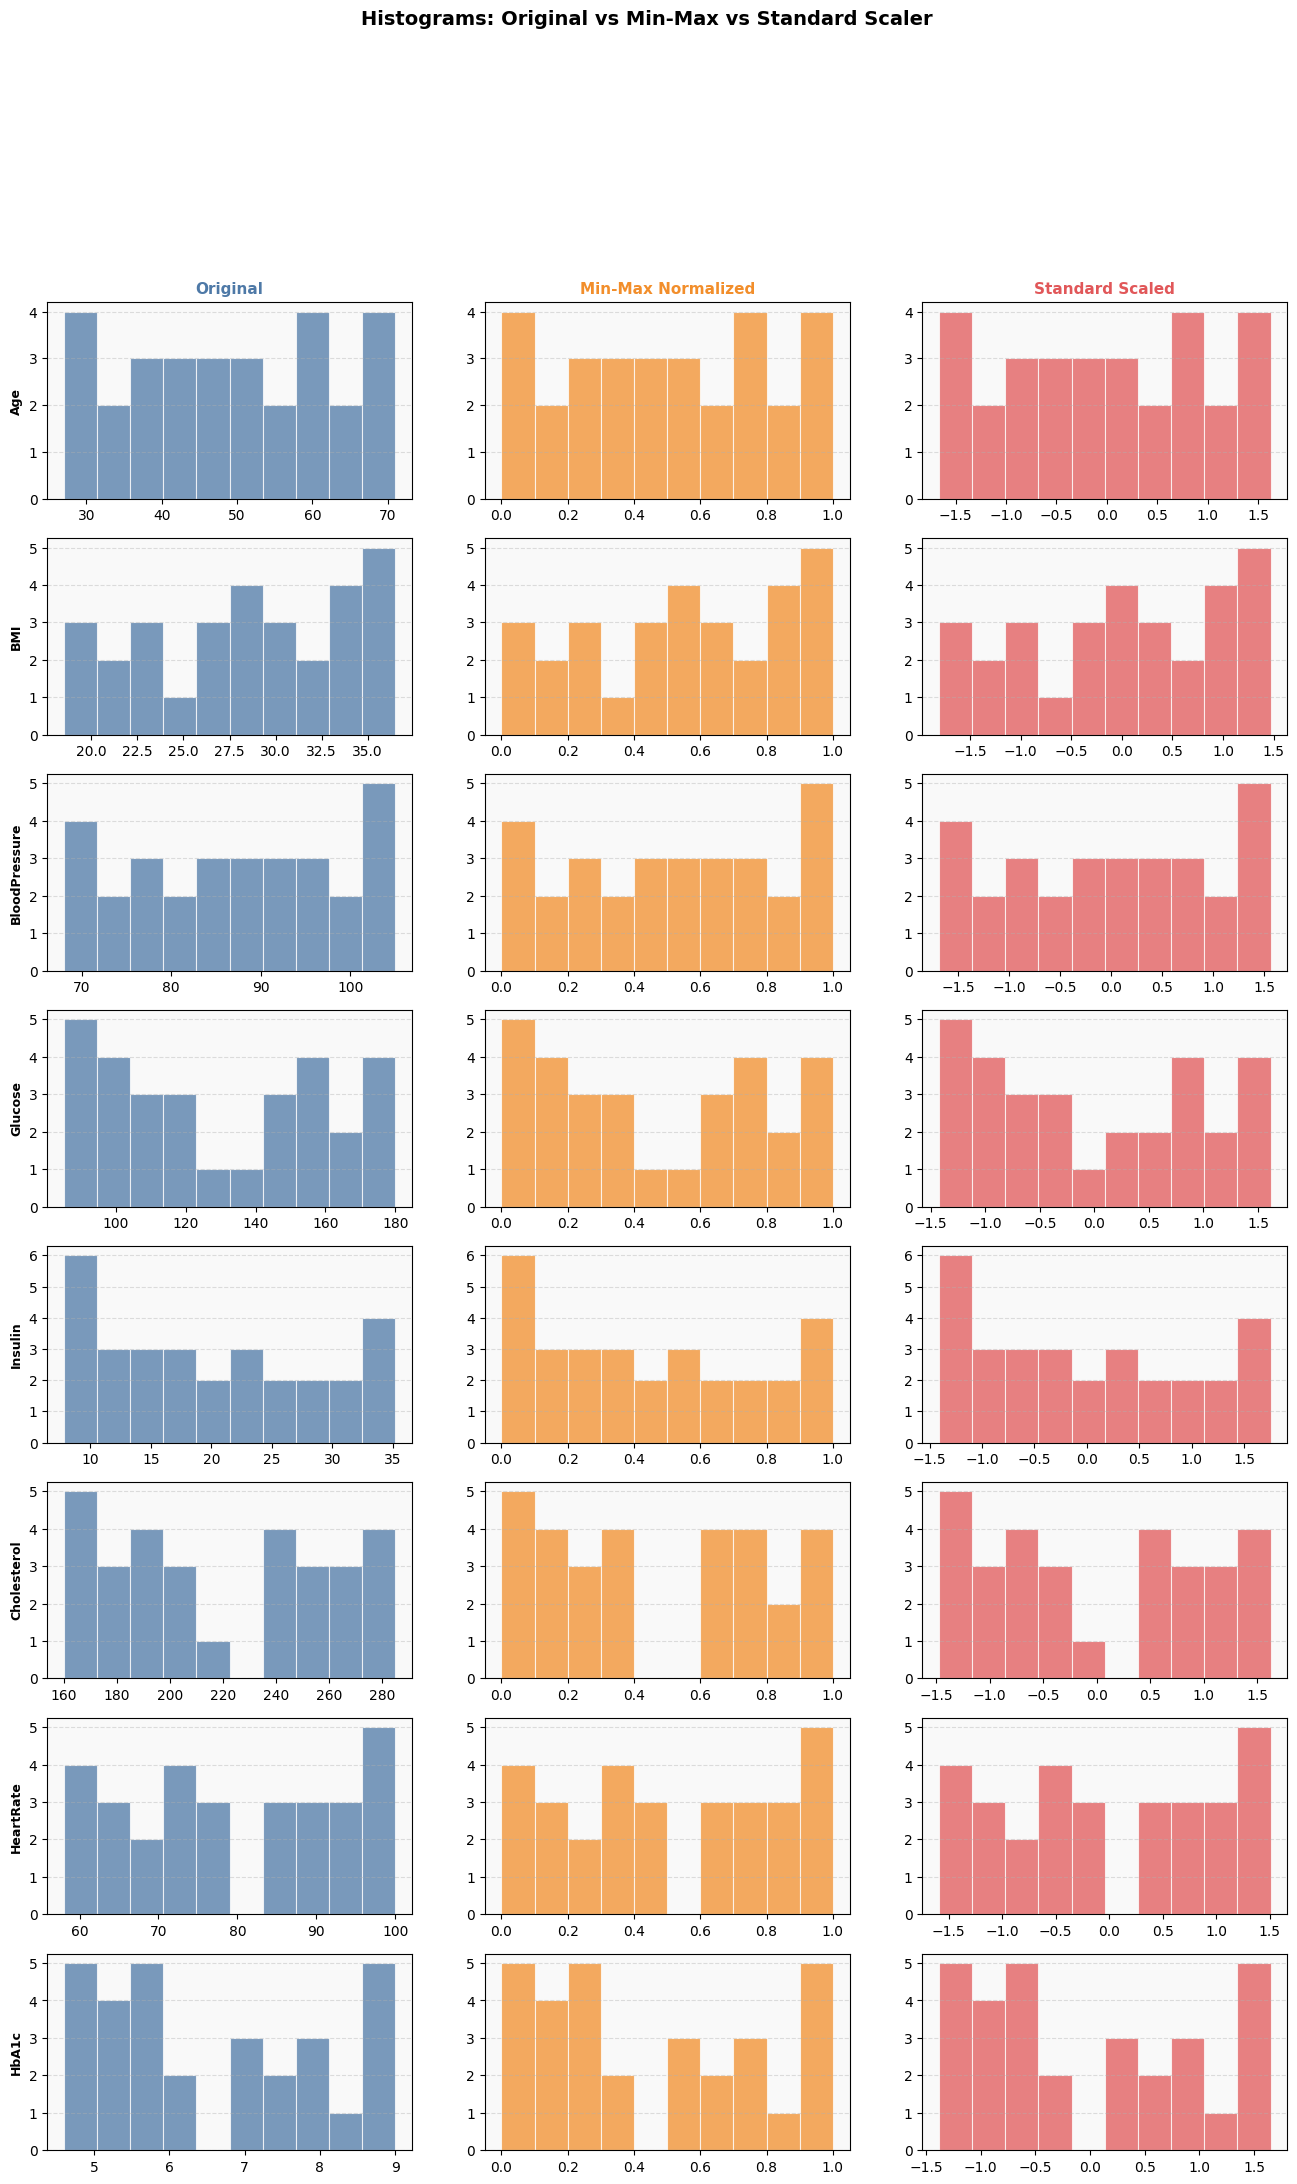

In [28]:
# PLOT 2  —  Histograms  
# ════════════════════
fig, axes = plt.subplots(n_feat, 3, figsize=(16,3*n_feat))
fig.suptitle("Histograms: Original vs Min-Max vs Standard Scaler",fontsize=14, fontweight="bold", y=1.002)
col_cfg = [("Original",          "#4e79a7"), ("Min-Max Normalized","#f28e2b"),("Standard Scaled",   "#e15759"),]
for i, feat in enumerate(features):
    for j, (data, (ctitle, color)) in enumerate(
            zip([X, X_mm, X_ss], col_cfg)):
        ax = axes[i, j]
        ax.hist(data[feat], bins=10, color=color,
                alpha=0.75, edgecolor="white", linewidth=0.8)
        if i == 0:
            ax.set_title(ctitle, fontsize=11,
                         fontweight="bold", color=color)
        if j == 0:
            ax.set_ylabel(feat, fontsize=9, fontweight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.set_facecolor("#f9f9f9")

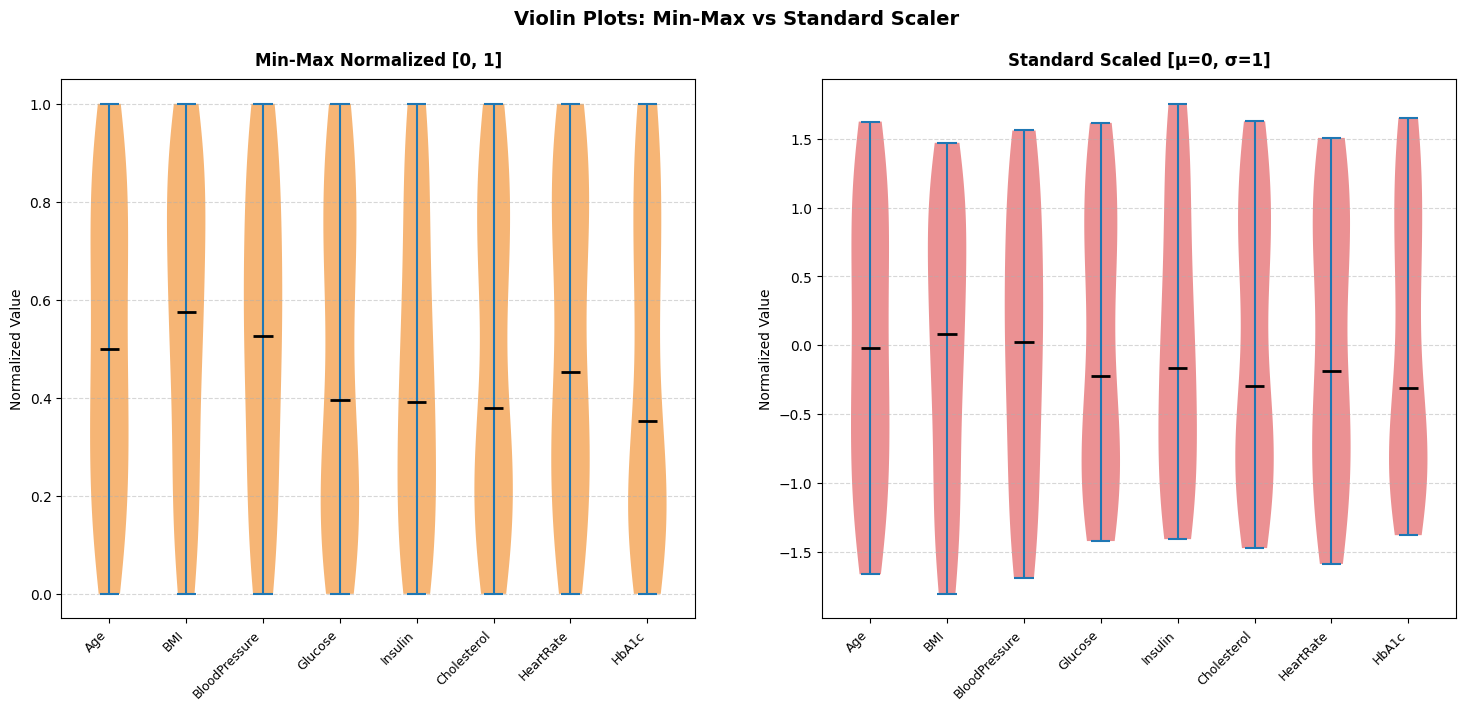

In [15]:
# PLOT 3  —  Violin Plots 
# ════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Violin Plots: Min-Max vs Standard Scaler",
             fontsize=14, fontweight="bold")

for ax, data, title, color in zip(axes,[X_mm, X_ss],
        ["Min-Max Normalized [0, 1]", "Standard Scaled [μ=0, σ=1]"],
        ["#f28e2b", "#e15759"]):
    parts = ax.violinplot(data.values,
                          positions=range(1, n_feat + 1),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(range(1, n_feat + 1))
    ax.set_xticklabels(features, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Normalized Value", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

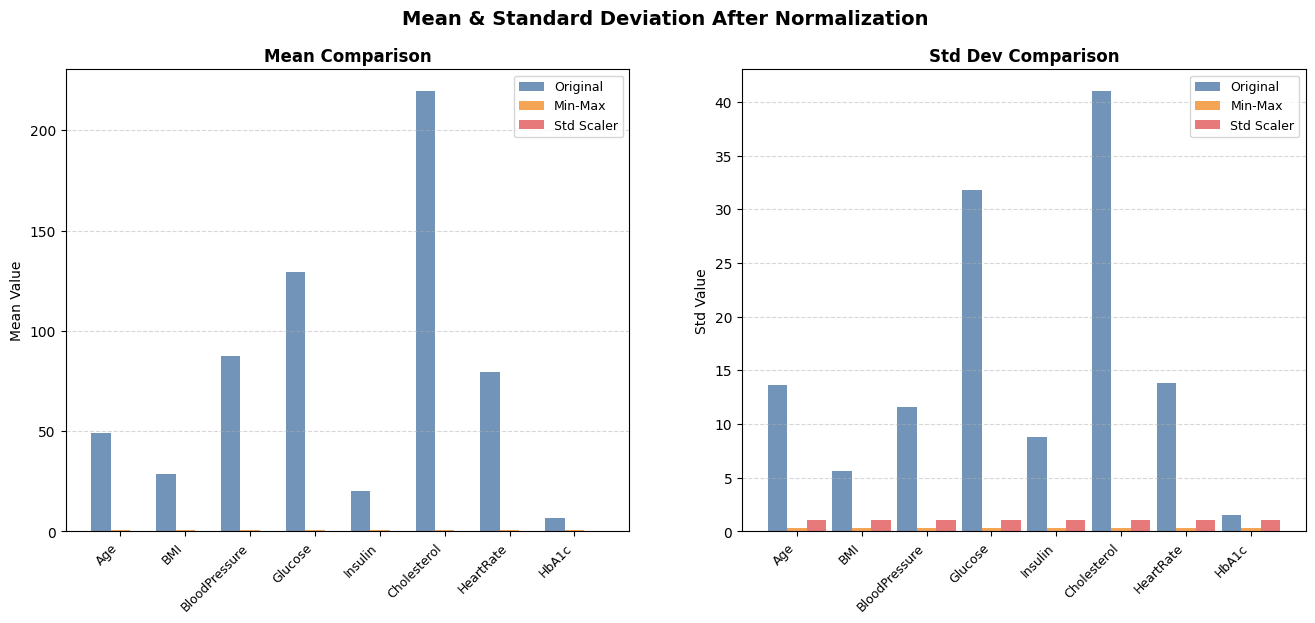

In [29]:
# PLOT 4  —  Mean & Std-Dev Bar Charts
# ════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Mean & Standard Deviation After Normalization",
             fontsize=14, fontweight="bold")

x = np.arange(n_feat)
width = 0.3

for ax, metric, title in zip(
        axes,
        ["mean", "std"],
        ["Mean Comparison", "Std Dev Comparison"]):
    orig_v = X.agg(metric).values
    mm_v   = X_mm.agg(metric).values
    ss_v   = X_ss.agg(metric).values

    ax.bar(x - width, orig_v, width, label="Original",    color="#4e79a7", alpha=0.8)
    ax.bar(x,         mm_v,   width, label="Min-Max",     color="#f28e2b", alpha=0.8)
    ax.bar(x + width, ss_v,   width, label="Std Scaler",  color="#e15759", alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric.capitalize() + " Value", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)


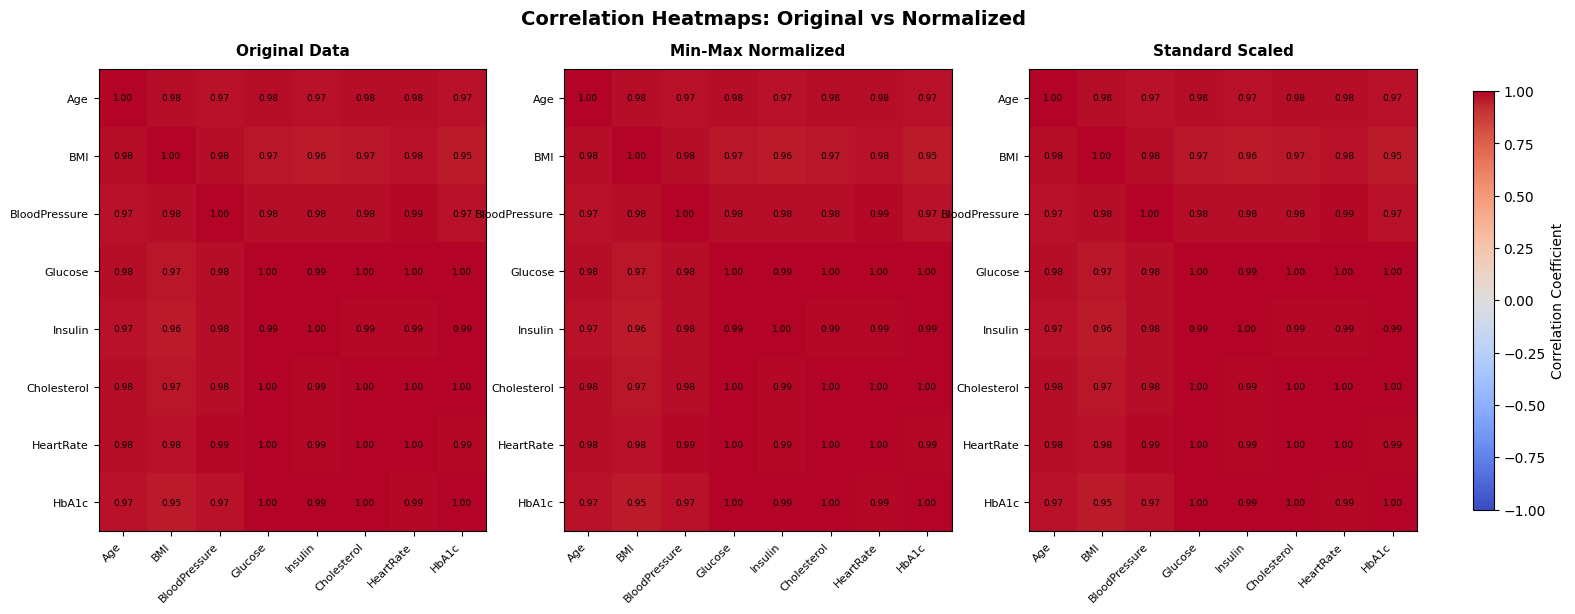

In [33]:
# PLOT 5— Correlation Heatmaps
# ══════════════════════════
def draw_heatmap(ax, data, title):
    corr = data.corr()
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(n_feat))
    ax.set_yticks(range(n_feat))
    ax.set_xticklabels(features, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(features, fontsize=8)
    for i in range(n_feat):
        for j in range(n_feat):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                    ha="center", va="center",
                    fontsize=6.5, color="black")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    return im

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Correlation Heatmaps: Original vs Normalized",
             fontsize=14, fontweight="bold")

im = draw_heatmap(axes[0], X,    "Original Data")
draw_heatmap(axes[1], X_mm, "Min-Max Normalized")
draw_heatmap(axes[2], X_ss, "Standard Scaled")

plt.colorbar(im, ax=axes, orientation="vertical",
fraction=0.015, pad=0.04, label="Correlation Coefficient")

In [34]:
# Summary Table
# ─────────────
print("  NORMALIZATION SUMMARY")
summary = pd.DataFrame({
    "Feature"     : features,
    "Orig Min"    : X.min().round(2).values,
    "Orig Max"    : X.max().round(2).values,
    "MM Min"      : X_mm.min().round(4).values,
    "MM Max"      : X_mm.max().round(4).values,
    "Std Mean"    : X_ss.mean().round(4).values,
    "Std StdDev"  : X_ss.std().round(4).values,
})
print(summary.to_string(index=False))

  NORMALIZATION SUMMARY
      Feature  Orig Min  Orig Max  MM Min  MM Max  Std Mean  Std StdDev
          Age      27.0      71.0     0.0     1.0       0.0      1.0171
          BMI      18.5      36.5     0.0     1.0      -0.0      1.0171
BloodPressure      68.0     105.0     0.0     1.0      -0.0      1.0171
      Glucose      85.0     180.0     0.0     1.0       0.0      1.0171
      Insulin       7.8      35.2     0.0     1.0       0.0      1.0171
  Cholesterol     160.0     285.0     0.0     1.0      -0.0      1.0171
    HeartRate      58.0     100.0     0.0     1.0       0.0      1.0171
        HbA1c       4.6       9.0     0.0     1.0      -0.0      1.0171
